# Finetunear theia con RGB-D

Explicar qué y por qué se hará el fine-tuning de theia

primero se descarga un modelo bebe (theia small)

### Dataset
Aqui explicar porqué se usa ese data y así...

In [1]:
import h5py
from pathlib import Path

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
import torchvision.transforms as T


class NYUDepthV2Mat(Dataset):
    """
    Dataset para 'nyu_depth_v2_labeled.mat' con el layout que tú ya verificaste:

      images: (N, 3, 640, 480)
      depths: (N, 640, 480)
      labels: (N, 640, 480)

    Devuelve:
      - rgb:   [3, 224, 224] float32 en [0,1]
      - depth: [1, 224, 224] float32 (valores originales de NYU)
      - label: [1, 224, 224] long (opcional, por si luego quieres segmentación)
    """
    def __init__(self, mat_path, resize=(224, 224), use_labels=False):
        super().__init__()
        self.mat_path = Path(mat_path)
        if not self.mat_path.exists():
            raise FileNotFoundError(f"No se encontró el archivo: {self.mat_path}")

        self.resize = resize
        self.use_labels = use_labels

        self._file = None  # se abre lazy por worker

        # Abrimos una vez sólo para leer shapes
        with h5py.File(self.mat_path, "r") as f:
            images_ds = f["images"]
            depths_ds = f["depths"]

            img_shape = images_ds.shape   # (N,3,640,480)
            depth_shape = depths_ds.shape # (N,640,480)

            if len(img_shape) != 4 or img_shape[1] != 3:
                raise RuntimeError(f"images tiene shape raro: {img_shape}, esperaba (N,3,640,480)")
            if len(depth_shape) != 3 or depth_shape[0] != img_shape[0]:
                raise RuntimeError(f"depths tiene shape raro: {depth_shape}, esperado N coherente con images")

            self.N = img_shape[0]

            if self.use_labels:
                labels_ds = f["labels"]
                label_shape = labels_ds.shape
                if len(label_shape) != 3 or label_shape[0] != self.N:
                    raise RuntimeError(f"labels tiene shape raro: {label_shape}")

        # Transform para RGB
        self.rgb_transform = T.Compose([
            T.Resize(self.resize, interpolation=T.InterpolationMode.BILINEAR),
            T.ToTensor(),  # [3,H,W] en [0,1]
        ])

        self.depth_size = self.resize

    def _ensure_file(self):
        # h5py + num_workers => cada worker abre su propio archivo
        if self._file is None:
            self._file = h5py.File(self.mat_path, "r")
            self.images_ds = self._file["images"]   # (N,3,640,480)
            self.depths_ds = self._file["depths"]   # (N,640,480)
            if self.use_labels:
                self.labels_ds = self._file["labels"]  # (N,640,480)

    def __len__(self):
        return self.N
    

    def __getitem__(self, idx):
        self._ensure_file()

        # ---------- RGB ----------
        img_raw = self.images_ds[idx]                  # [3,640,480]
        img_np = np.transpose(img_raw, (2, 1, 0))      # [480,640,3]
        img_np = img_np.astype(np.uint8)

        img_pil = Image.fromarray(img_np, mode="RGB")
        rgb = self.rgb_transform(img_pil)              # [3,224,224]

        # ---------- Depth ----------
        depth_raw = self.depths_ds[idx]                # [640,480]
        depth_np = np.array(depth_raw, dtype=np.float32).T   # [480,640]
        depth_pil = Image.fromarray(depth_np)          # modo 'F'
        depth_pil = depth_pil.resize(self.depth_size, resample=Image.NEAREST)
        depth_resized = np.array(depth_pil, dtype=np.float32)
        depth = torch.from_numpy(depth_resized).unsqueeze(0)   # [1,224,224]

        sample = {
            "rgb": rgb,
            "depth": depth,
            "index": idx,
        }

        # ---------- Labels (arreglo aquí) ----------
        if self.use_labels:
            label_raw = self.labels_ds[idx]            # [640,480], int64
            label_np = np.array(label_raw, dtype=np.int32).T   # [480,640], int32

            # PIL necesita saber que es imagen de enteros -> modo "I"
            label_pil = Image.fromarray(label_np, mode="I")
            label_pil = label_pil.resize(self.depth_size, resample=Image.NEAREST)

            label_resized = np.array(label_pil, dtype=np.int64)   # regresamos a int64
            label = torch.from_numpy(label_resized).unsqueeze(0)  # [1,224,224]
            sample["label"] = label

        return sample


In [ ]:
from torch.utils.data import DataLoader

mat_path = "nyu_depth_v2_labeled.mat"  # o la ruta que uses

dataset = NYUDepthV2Mat(mat_path, resize=(224, 224), use_labels=True)
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True,)

batch = next(iter(loader))
print("rgb:", batch["rgb"].shape)        # [4,3,224,224]
print("depth:", batch["depth"].shape)    # [4,1,224,224]
print("label:", batch["label"].shape)    # [4,1,224,224]
print("rgb min/max:", batch["rgb"].min().item(), batch["rgb"].max().item())
print("depth min/max:", batch["depth"].min().item(), batch["depth"].max().item())
print("label uniq (ejemplo):", torch.unique(batch["label"])[:10])


In [ ]:
import torch
from transformers import AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---- DESCARGAR MODELO ----
model = AutoModel.from_pretrained(
    "theaiinstitute/theia-small-patch16-224-cdiv",
    trust_remote_code=True
).to(device).eval()

# ---- PROBAR UN FORWARD ----
# fake image 224x224 RGB
x = torch.zeros(1, 224, 224, 3, dtype=torch.uint8).to(device)

with torch.no_grad():
    feat = model.forward_feature(x)   # <- vector semántico de Theia

with torch.no_grad():
    out = model.forward_feature(x)

print("Feature shape:", feat.shape)

print("Shape:", out.shape)
print("Min:", out.min().item(), "Max:", out.max().item())
print(type(out))

print("primer token",out[:, 0].shape)     # primer token
print("Los demás:", out[:, 1:].shape)    # los demás

## BackBone 2D

Definir el backbone 2d

In [2]:
import torch
import torch.nn as nn
from transformers import AutoModel


class TheiaBackbone2D(nn.Module):
    """
    Wrapper sencillo de Theia:
    - Input: [B, 3, H, W] o [B, H, W, 3] (RGB)
    - Output: [B, D]  (feature global por imagen)
    """
    #def __init__(self, model_name: str = "theaiinstitute/theia-small-patch16-224-cdiv"):
    def __init__(self, model_name: str = "theaiinstitute/theia-base-patch16-224-cdiv"):
        super().__init__()
        self.model = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True,
        )

    @torch.no_grad()
    def _ensure_uint8(self, x: torch.Tensor) -> torch.Tensor:
        """
        Theia espera uint8 [0,255]. Aceptamos float y lo normalizamos.
        """
        if x.dtype == torch.uint8:
            return x

        # si viene en float, asumimos [0,1] o [0,255]
        x = x.clamp(0.0, 255.0)
        if x.max() <= 1.0:
            x = x * 255.0
        return x.to(torch.uint8)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, 3, H, W] o [B, H, W, 3]
        devuelve: [B, D]
        """
        x = self._ensure_uint8(x)
        # Esto te estaba regresando [B, 196, 384]
        feat_tokens = self.model.forward_feature(x)  # [B, N, D]
        # Pooling simple: promedio sobre tokens
        feat_global = feat_tokens.mean(dim=1)        # [B, D]
        return feat_global


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

backbone = TheiaBackbone2D().to(device).eval()

# batch fake
x = torch.zeros(4, 3, 224, 224, dtype=torch.float32).to(device)

with torch.no_grad():
    feat = backbone(x)

print("Backbone feature shape:", feat.shape)


In [ ]:
class TheiaClassifier(nn.Module):
    """
    Theia + MLP chiquito para clasificación.
    Luego podemos:
      - freeze backbone y entrenar solo la cabeza
      - o fine-tunear todo
    """
    def __init__(self, n_classes: int, model_name: str = "theaiinstitute/theia-small-patch16-224-cdiv",
                 freeze_backbone: bool = True):
        super().__init__()
        self.backbone = TheiaBackbone2D(model_name=model_name)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # calculamos dim de feature
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224, dtype=torch.float32)
            feat_dim = self.backbone(dummy).shape[-1]

        hidden = feat_dim // 2

        self.head = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone(x)   # [B, D]
        logits = self.head(feat)  # [B, n_classes]
        return logits


In [ ]:
model = TheiaClassifier(n_classes=10).to(device)
x = torch.zeros(8, 3, 224, 224, dtype=torch.float32).to(device)

with torch.no_grad():
    logits = model(x)

print("Logits shape:", logits.shape)

### Student

Definimos el student RGBD, será un theiabackbone RGBD

In [3]:
import torch
import torch.nn as nn
from transformers import AutoModel


def _find_patch_conv(model: nn.Module):
    candidates = []
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            k = m.kernel_size
            s = m.stride
            if (
                m.in_channels == 3 and
                k[0] == k[1] == 16 and
                s[0] == s[1] == 16
            ):
                candidates.append((name, m))

    if len(candidates) == 0:
        raise RuntimeError("No encontré Conv2d de patch embedding (3 canales, k=16, s=16)")
    if len(candidates) > 1:
        print("Advertencia: encontré múltiples candidatos, uso el primero:")
        for name, _ in candidates:
            print(" -", name)
    return candidates[0]  # (name, module)


class ResBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        out = out + x
        out = self.relu(out)
        return out


class TheiaBackboneRGBD(nn.Module):
    def __init__(
        self,

        model_name: str = "theaiinstitute/theia-base-patch16-224-cdiv",
        #model_name: str = "theaiinstitute/theia-small-patch16-224-cdiv",
        use_cls_token: bool = False,
    ):
        super().__init__()
        self.model = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True,
        )
        self.use_cls_token = use_cls_token

        # ===== STEM RESIDUAL PARA FUSIONAR RGB+DEPTH =====
        stem_channels = 32
        self.stem_in = nn.Conv2d(4, stem_channels, kernel_size=3, padding=1)
        self.stem_block1 = ResBlock(stem_channels)
        self.stem_block2 = ResBlock(stem_channels)
        self.stem_out = nn.Conv2d(stem_channels, 4, kernel_size=3, padding=1)
        self.stem_relu = nn.ReLU(inplace=True)

        # Parchear patch embedding a 4 canales
        self._convert_patch_embed_to_rgbd()

        # Guardar dim de embedding para DepthHead / classifier
        try:
            vit = self.model.backbone.model          # ViTModel
            self.embed_dim = vit.config.hidden_size
        except Exception:
            self.embed_dim = self.model.config.hidden_size

    @torch.no_grad()
    def _preprocess_rgbd(self, x: torch.Tensor) -> torch.Tensor:
        # [B,4,H,W] o [B,H,W,4] -> [B,4,H,W] float32 en ~[0,1]
        if x.ndim == 4 and x.shape[1] not in (3, 4):
            x = x.permute(0, 3, 1, 2).contiguous()

        if x.dtype == torch.uint8:
            x = x.float() / 255.0
        else:
            if x.max() > 1.5:
                x = x / 255.0
        return x.to(torch.float32)

    def _convert_patch_embed_to_rgbd(self):
        name, old_conv = _find_patch_conv(self.model)
        print(f"[RGBD] Patch embedding encontrado en: {name}  (in={old_conv.in_channels}, out={old_conv.out_channels})")

        in_c = 4
        out_c = old_conv.out_channels
        k = old_conv.kernel_size
        s = old_conv.stride
        p = old_conv.padding
        d = old_conv.dilation
        bias = old_conv.bias is not None

        new_conv = nn.Conv2d(
            in_channels=in_c,
            out_channels=out_c,
            kernel_size=k,
            stride=s,
            padding=p,
            dilation=d,
            bias=bias,
        )

        with torch.no_grad():
            # Copiar RGB
            new_conv.weight[:, :3, :, :] = old_conv.weight
            # Canal D = promedio de los 3
            mean_w = old_conv.weight.mean(dim=1, keepdim=True)
            new_conv.weight[:, 3:4, :, :] = mean_w
            if bias:
                new_conv.bias.copy_(old_conv.bias)

        # Reemplazar el conv dentro del modelo
        modules = name.split(".")
        parent = self.model
        for m in modules[:-1]:
            parent = getattr(parent, m)
        setattr(parent, modules[-1], new_conv)

        # Ajustar num_channels en ViT
        try:
            vit = self.model.backbone.model          # ViTModel
            vit.config.num_channels = 4
            if hasattr(vit, "embeddings"):
                pe = vit.embeddings.patch_embeddings  # ViTPatchEmbeddings
                pe.num_channels = 4
        except Exception as e:
            print("[RGBD] Advertencia al ajustar num_channels:", e)

        print("[RGBD] Patch embedding convertido a 4 canales (RGBD).")

    def forward_tokens(self, x: torch.Tensor) -> torch.Tensor:
        # Preprocesar
        x = self._preprocess_rgbd(x)          # [B,4,H,W] float32 en [0,1]

        # STEM residual: 4 -> 32 -> 32 -> 4
        x = self.stem_in(x)                   # [B,32,H,W]
        x = self.stem_relu(x)
        x = self.stem_block1(x)               # [B,32,H,W]
        x = self.stem_block2(x)               # [B,32,H,W]
        x = self.stem_out(x)                  # [B,4,H,W]
        x = self.stem_relu(x)

        vit = self.model.backbone.model       # ViTModel
        out = vit(pixel_values=x)
        tokens = out.last_hidden_state        # [B, N, D]

        # Si hay CLS, lo quitamos para quedarnos con 196 patches
        if tokens.shape[1] == 197 and not self.use_cls_token:
            tokens = tokens[:, 1:, :]

        return tokens

    def forward_global(self, x: torch.Tensor) -> torch.Tensor:
        tokens = self.forward_tokens(x)       # [B,N,D]
        return tokens.mean(dim=1)             # [B,D]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.forward_global(x)
"""

import torch
import torch.nn as nn
from transformers import AutoModel


def _find_patch_conv(model: nn.Module):
    candidates = []
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            k = m.kernel_size
            s = m.stride
            if (
                m.in_channels == 3 and
                k[0] == k[1] == 16 and
                s[0] == s[1] == 16
            ):
                candidates.append((name, m))

    if len(candidates) == 0:
        raise RuntimeError("No encontré Conv2d de patch embedding (3 canales, k=16, s=16)")
    if len(candidates) > 1:
        print("Advertencia: encontré múltiples candidatos, uso el primero:")
        for name, _ in candidates:
            print(" -", name)
    return candidates[0]  # (name, module)


class ResBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        out = out + x
        out = self.relu(out)
        return out


class TheiaBackboneRGBD(nn.Module):
    def __init__(
        self,
        model_name: str = "theaiinstitute/theia-small-patch16-224-cdiv",
        use_cls_token: bool = False,
    ):
        super().__init__()
        self.model = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True,
        )
        self.use_cls_token = use_cls_token

        # ===== STEM DUAL: RGB y DEPTH por separado =====
        # Rama RGB
        rgb_ch = 32
        self.rgb_in = nn.Conv2d(3, rgb_ch, kernel_size=3, padding=1)
        self.rgb_block1 = ResBlock(rgb_ch)
        self.rgb_block2 = ResBlock(rgb_ch)

        # Rama Depth
        d_ch = 16
        self.d_in = nn.Conv2d(1, d_ch, kernel_size=3, padding=1)
        self.d_block1 = ResBlock(d_ch)
        self.d_block2 = ResBlock(d_ch)

        # Fusión cruzada: [rgb_ch + d_ch] -> 4 canales (RGBD refinado)
        self.fuse = nn.Conv2d(rgb_ch + d_ch, 4, kernel_size=3, padding=1)
        self.fuse_relu = nn.ReLU(inplace=True)

        # Parchear patch embedding a 4 canales (como ya lo hacías)
        self._convert_patch_embed_to_rgbd()

        # Guardar dim de embedding para DepthHead / classifier
        try:
            vit = self.model.backbone.model          # ViTModel
            self.embed_dim = vit.config.hidden_size
        except Exception:
            self.embed_dim = self.model.config.hidden_size

    @torch.no_grad()
    def _preprocess_rgbd(self, x: torch.Tensor) -> torch.Tensor:
        # [B,4,H,W] o [B,H,W,4] -> [B,4,H,W] float32 en ~[0,1]
        if x.ndim == 4 and x.shape[1] not in (3, 4):
            x = x.permute(0, 3, 1, 2).contiguous()

        if x.dtype == torch.uint8:
            x = x.float() / 255.0
        else:
            if x.max() > 1.5:
                x = x / 255.0
        return x.to(torch.float32)

    def _convert_patch_embed_to_rgbd(self):
        name, old_conv = _find_patch_conv(self.model)
        print(f"[RGBD] Patch embedding encontrado en: {name}  (in={old_conv.in_channels}, out={old_conv.out_channels})")

        in_c = 4
        out_c = old_conv.out_channels
        k = old_conv.kernel_size
        s = old_conv.stride
        p = old_conv.padding
        d = old_conv.dilation
        bias = old_conv.bias is not None

        new_conv = nn.Conv2d(
            in_channels=in_c,
            out_channels=out_c,
            kernel_size=k,
            stride=s,
            padding=p,
            dilation=d,
            bias=bias,
        )

        with torch.no_grad():
            # Copiar RGB
            new_conv.weight[:, :3, :, :] = old_conv.weight
            # Canal D = promedio de los 3
            mean_w = old_conv.weight.mean(dim=1, keepdim=True)
            new_conv.weight[:, 3:4, :, :] = mean_w
            if bias:
                new_conv.bias.copy_(old_conv.bias)

        # Reemplazar el conv dentro del modelo
        modules = name.split(".")
        parent = self.model
        for m in modules[:-1]:
            parent = getattr(parent, m)
        setattr(parent, modules[-1], new_conv)

        # Ajustar num_channels en ViT
        try:
            vit = self.model.backbone.model          # ViTModel
            vit.config.num_channels = 4
            if hasattr(vit, "embeddings"):
                pe = vit.embeddings.patch_embeddings  # ViTPatchEmbeddings
                pe.num_channels = 4
        except Exception as e:
            print("[RGBD] Advertencia al ajustar num_channels:", e)

        print("[RGBD] Patch embedding convertido a 4 canales (RGBD).")

    def forward_tokens(self, x: torch.Tensor) -> torch.Tensor:
        # Preprocesar
        x = self._preprocess_rgbd(x)          # [B,4,H,W] float32 en [0,1]

        # Separar RGB y depth
        rgb = x[:, :3, :, :]                  # [B,3,H,W]
        d   = x[:, 3:4, :, :]                 # [B,1,H,W]

        # ----- Rama RGB -----
        rgb = self.rgb_in(rgb)                # [B,32,H,W]
        rgb = self.rgb_block1(rgb)
        rgb = self.rgb_block2(rgb)

        # ----- Rama Depth -----
        d = self.d_in(d)                      # [B,16,H,W]
        d = self.d_block1(d)
        d = self.d_block2(d)

        # ----- Fusión cruzada -----
        feat = torch.cat([rgb, d], dim=1)     # [B,48,H,W]
        feat = self.fuse(feat)                # [B,4,H,W]
        feat = self.fuse_relu(feat)

        vit = self.model.backbone.model       # ViTModel
        out = vit(pixel_values=feat)
        tokens = out.last_hidden_state        # [B, N, D]

        # Si hay CLS y no lo queremos, lo quitamos
        if tokens.shape[1] == 197 and not self.use_cls_token:
            tokens = tokens[:, 1:, :]

        return tokens

    def forward_global(self, x: torch.Tensor) -> torch.Tensor:
        tokens = self.forward_tokens(x)       # [B,N,D]
        return tokens.mean(dim=1)             # [B,D]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.forward_global(x)

"""

'\n\nimport torch\nimport torch.nn as nn\nfrom transformers import AutoModel\n\n\ndef _find_patch_conv(model: nn.Module):\n    candidates = []\n    for name, m in model.named_modules():\n        if isinstance(m, nn.Conv2d):\n            k = m.kernel_size\n            s = m.stride\n            if (\n                m.in_channels == 3 and\n                k[0] == k[1] == 16 and\n                s[0] == s[1] == 16\n            ):\n                candidates.append((name, m))\n\n    if len(candidates) == 0:\n        raise RuntimeError("No encontré Conv2d de patch embedding (3 canales, k=16, s=16)")\n    if len(candidates) > 1:\n        print("Advertencia: encontré múltiples candidatos, uso el primero:")\n        for name, _ in candidates:\n            print(" -", name)\n    return candidates[0]  # (name, module)\n\n\nclass ResBlock(nn.Module):\n    def __init__(self, channels: int):\n        super().__init__()\n        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)\n 

### Datos fakeeees


se prueba

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

student_rgbd = TheiaBackboneRGBD().to(device).eval()

x_rgbd = torch.zeros(2, 4, 224, 224, dtype=torch.float32).to(device)

with torch.no_grad():
    tokens = student_rgbd.forward_tokens(x_rgbd)
    feat_global = student_rgbd.forward_global(x_rgbd)

print("Tokens shape:", tokens.shape)
print("Global feature shape:", feat_global.shape)


### Head de profundidad

se define un mapa [B,D,14,14]

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        out = out + x
        out = self.relu(out)
        return out


class DepthHead(nn.Module):
   
    def __init__(self, embed_dim: int):
        super().__init__()

        # Canales por escala (ajustados a embed_dim)
        C0 = min(256, embed_dim)        # 14x14
        C1 = max(C0 // 2, 64)           # 28x28
        C2 = max(C1 // 2, 64)           # 56x56
        C3 = max(C2 // 2, 32)           # 112x112
        C4 = max(C3 // 2, 32)           # 224x224 (antes de la conv final)

        # Proyección inicial de tokens a feature map
        self.proj = nn.Conv2d(embed_dim, C0, kernel_size=1)

        # Bloques por escala
        self.block0 = nn.Sequential(
            ResBlock(C0),
            ResBlock(C0),
        )

        self.block1 = nn.Sequential(
            nn.Conv2d(C0, C1, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            ResBlock(C1),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(C1, C2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            ResBlock(C2),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(C2, C3, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            ResBlock(C3),
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(C3, C4, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            ResBlock(C4),
        )

        # Conv final a 1 canal
        self.conv_out = nn.Conv2d(C4, 1, kernel_size=3, padding=1)

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        B, N, D = tokens.shape
        S = int(N ** 0.5)
        assert S * S == N, "N de tokens no es cuadrado, revisa resolución / patch size"

        # [B,N,D] -> [B,D,S,S]
        x = tokens.transpose(1, 2).reshape(B, D, S, S)  # [B,D,14,14]

        # proj + resblocks en 14x14
        x = self.proj(x)      # [B,C0,14,14]
        x = self.block0(x)

        # 14 -> 28
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.block1(x)    # [B,C1,28,28]

        # 28 -> 56
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.block2(x)    # [B,C2,56,56]

        # 56 -> 112
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.block3(x)    # [B,C3,112,112]

        # 112 -> 224
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.block4(x)    # [B,C4,224,224]

        depth = self.conv_out(x)   # [B,1,224,224]
        return depth
    
    """
import torch
import torch.nn as nn
import torch.nn.functional as F


class DepthHeadUNet(nn.Module):
    def __init__(self, embed_dim: int):
        super().__init__()

        self.embed_dim = embed_dim

        # --- 14x14 ---
        self.conv_in = nn.Conv2d(embed_dim, 256, kernel_size=3, padding=1)

        # --- 28x28 ---
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv1 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        # --- 56x56 ---
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # --- 112x112 ---
        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, padding=1)

        # --- 224x224 ---
        self.up4 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.conv4 = nn.Conv2d(16, 16, kernel_size=3, padding=1)

        # Salida final 1 canal
        self.out_conv = nn.Conv2d(16, 1, kernel_size=1)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, tokens):
        B, N, D = tokens.shape
        S = int(N ** 0.5)        # debería ser 14x14 para patch16

        x = tokens.transpose(1, 2).reshape(B, D, S, S)  # [B,D,14,14]
        x = self.relu(self.conv_in(x))                  # [B,256,14,14]

        # --- Decoding ---
        x = self.relu(self.conv1(self.up1(x)))          # [B,128,28,28]
        x = self.relu(self.conv2(self.up2(x)))          # [B,64,56,56]
        x = self.relu(self.conv3(self.up3(x)))          # [B,32,112,112]
        x = self.relu(self.conv4(self.up4(x)))          # [B,16,224,224]

        depth = self.out_conv(x)                        # [B,1,224,224]

        return depth
"""

## combinar student y backbone

se combinan los backbone

In [5]:
class TheiaRGBDStudent(nn.Module):
    """
    Student RGBD:
      - backbone: TheiaBackboneRGBD (tokens + feature global)
      - head de profundidad: DepthHead(tokens)
    """
    def __init__(self, model_name: str = "theaiinstitute/theia-base-patch16-224-cdiv"):
        super().__init__()
        self.backbone = TheiaBackboneRGBD(model_name=model_name)

        # averiguar dim de embedding con un dummy
        with torch.no_grad():
            dummy = torch.zeros(1, 4, 224, 224, dtype=torch.float32)
            tokens = self.backbone.forward_tokens(dummy)   # [1, N, D]
            embed_dim = tokens.shape[-1]

        self.depth_head = DepthHead(embed_dim)

    def forward(self, x_rgbd: torch.Tensor):
        """
        x_rgbd: [B, 4, 224, 224] (RGBD, ya más o menos normalizado)
        returns:
          feat_global: [B, D]
          depth_pred:  [B, 1, 224, 224]
        """
        tokens = self.backbone.forward_tokens(x_rgbd)   # [B, N, D]
        feat_global = tokens.mean(dim=1)                # [B, D]
        depth_pred = self.depth_head(tokens)            # [B, 1, 224, 224]
        return feat_global, depth_pred


### PRuebita del student


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

student = TheiaRGBDStudent().to(device).eval()

x_rgbd = torch.zeros(2, 4, 224, 224, dtype=torch.float32).to(device)

with torch.no_grad():
    feat_global, depth_pred = student(x_rgbd)

print("feat_global:", feat_global.shape)   # [2, D]
print("depth_pred:", depth_pred.shape)     # [2, 1, 224, 224]


In [6]:
import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

# Pesos de las pérdidas
W_L1       = 1.0   # pérdida L1 de profundidad
W_GRAD     = 1.05   # pérdida de gradiente
W_SSIM     = 0.35   # pérdida SSIM
W_DISTILL  = 0.89   # distillation (cosine)


def gradient_loss(pred, target):
    """
    Penaliza diferencias de gradiente (bordes) entre pred y target.
    pred, target: [B,1,H,W] en [0,1]
    """
    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]

    tgt_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    tgt_dy = target[:, :, 1:, :] - target[:, :, :-1, :]

    Lx = (pred_dx - tgt_dx).abs().mean()
    Ly = (pred_dy - tgt_dy).abs().mean()
    return Lx + Ly


def ssim_loss(pred, target):
    """
    SSIM loss en [0,1], versión sencilla.
    pred, target: [B,1,H,W] en [0,1]
    """
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu_pred   = F.avg_pool2d(pred, 3, 1, 0)
    mu_target = F.avg_pool2d(target, 3, 1, 0)

    sigma_pred   = F.avg_pool2d(pred * pred, 3, 1, 0) - mu_pred ** 2
    sigma_target = F.avg_pool2d(target * target, 3, 1, 0) - mu_target ** 2
    sigma_xy     = F.avg_pool2d(pred * target, 3, 1, 0) - mu_pred * mu_target

    ssim_n = (2 * mu_pred * mu_target + C1) * (2 * sigma_xy + C2)
    ssim_d = (mu_pred ** 2 + mu_target ** 2 + C1) * (sigma_pred + sigma_target + C2)

    ssim_map = ssim_n / (ssim_d + 1e-7)
    # convertimos SSIM a "pérdida"
    loss = torch.clamp((1.0 - ssim_map) / 2.0, 0.0, 1.0)
    return loss.mean()


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- Instanciar dataset y dataloader ----------
mat_path = "nyu_depth_v2_labeled.mat"  # ajusta ruta si hace falta

train_ds = NYUDepthV2Mat(mat_path, resize=(224, 224), use_labels=False)
train_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=16,         # puedes bajar a 2 si te duele la VRAM
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

# ---------- Teacher 2D (congelado) ----------
teacher = TheiaBackbone2D().to(device).eval()
for p in teacher.parameters():
    p.requires_grad = False

# ---------- Student RGBD ----------
student = TheiaRGBDStudent().to(device).train()

# ---------- Optimizador + AMP ----------
opt = torch.optim.AdamW(student.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = GradScaler()

MAX_DEPTH_METERS = 10.0      # clip para normalizar depth
LAMBDA_DEPTH = 1.0           # peso de la pérdida de profundidad


"""def training_step(batch):
    rgb   = batch["rgb"].to(device)     # [B,3,224,224], float [0,1]
    depth = batch["depth"].to(device)   # [B,1,224,224], float (m)

    # --------- Normalizar depth a [0,1] y formar RGBD ---------
    depth_clipped = depth.clamp(0.0, MAX_DEPTH_METERS)
    depth_norm = depth_clipped / MAX_DEPTH_METERS          # [0,1]

    rgbd = torch.cat([rgb, depth_norm], dim=1)             # [B,4,224,224]

    # --------- Teacher (2D, congelado) ---------
    with torch.no_grad():
        feat_teacher = teacher(rgb)                        # [B,D]

    # --------- Student RGBD ---------
    with autocast(device_type="cuda", enabled=True):
        feat_student, depth_pred = student(rgbd)           # [B,D], [B,1,224,224]

        # Pérdida de distillation (feature-level)
        L_distill = F.mse_loss(feat_student, feat_teacher)

        # Pérdida de profundidad (L1) en escala [0,1]
        # comparamos contra depth_norm para que ambos estén en el mismo rango
        L_depth = F.l1_loss(depth_pred, depth_norm)

        L_total = L_distill + LAMBDA_DEPTH * L_depth

    return L_total, L_distill.detach(), L_depth.detach()"""


"""def training_step(batch):
    rgb   = batch["rgb"].to(device)
    depth = batch["depth"].to(device)

    depth_clipped = depth.clamp(0.0, MAX_DEPTH_METERS)
    depth_norm = depth_clipped / MAX_DEPTH_METERS

    rgbd = torch.cat([rgb, depth_norm], dim=1)

    with torch.no_grad():
        feat_teacher = teacher(rgb)

    # --------- Student con autocast ---------
    with torch.cuda.amp.autocast():
        feat_student, depth_pred = student(rgbd)

        L_distill = F.mse_loss(feat_student, feat_teacher)
        L_depth = F.l1_loss(depth_pred, depth_norm)

        L_total = L_distill + LAMBDA_DEPTH * L_depth

    return L_total, L_distill.detach(), L_depth.detach()
"""
"""
def training_step(batch):
    rgb   = batch["rgb"].to(device)   # [B,3,224,224], float [0,1]
    depth = batch["depth"].to(device) # [B,1,224,224], float (m)

    # --------- Normalizar depth a [0,1] ---------
    depth_clipped = depth.clamp(0.0, MAX_DEPTH_METERS)
    depth_norm = depth_clipped / MAX_DEPTH_METERS          # [0,1]

    # --------- Armar RGBD ---------
    rgbd = torch.cat([rgb, depth_norm], dim=1)             # [B,4,224,224]

    # --------- Teacher (2D, congelado) ---------
    with torch.no_grad():
        feat_teacher = teacher(rgb)                        # [B,D]

    # --------- Student RGBD con AMP ---------
    with torch.cuda.amp.autocast():
        feat_student, depth_pred = student(rgbd)           # [B,D], [B,1,224,224]

        # ----- Pérdida de profundidad -----
        L_depth_L1 = F.l1_loss(depth_pred, depth_norm)
        L_grad     = gradient_loss(depth_pred, depth_norm)
        L_ssim     = ssim_loss(depth_pred, depth_norm)

        # Combinamos las pérdidas de depth
        L_depth = (
            W_L1   * L_depth_L1 +
            W_GRAD * L_grad     +
            W_SSIM * L_ssim
        )

        # ----- Distillation: cosine en lugar de MSE -----
        cos_sim   = F.cosine_similarity(feat_student, feat_teacher, dim=1).mean()
        L_distill = 1.0 - cos_sim   # queremos que cos_sim sea 1

        # ----- Pérdida total -----
        L_total = L_depth + W_DISTILL * L_distill

    # Devolvemos L_total para backward y los otros para logging
    return L_total, L_distill.detach(), L_depth_L1.detach(), L_grad.detach(), L_ssim.detach()

"""

def training_step(batch):
    rgb   = batch["rgb"].to(device)    # [B,3,224,224], float [0,1]
    depth = batch["depth"].to(device)  # [B,1,224,224], float (m)

    # --------- Normalizar depth a [0,1] ---------
    depth_clipped = depth.clamp(0.0, MAX_DEPTH_METERS)
    depth_norm = depth_clipped / MAX_DEPTH_METERS          # [0,1]

    # --------- Armar RGBD ---------
    rgbd = torch.cat([rgb, depth_norm], dim=1)             # [B,4,224,224]

    # --------- Teacher (2D, congelado) ---------
    with torch.no_grad():
        feat_teacher = teacher(rgb)                        # [B,D]

    # --------- Student RGBD con AMP ---------
    with torch.cuda.amp.autocast():
        feat_student, depth_pred = student(rgbd)           # [B,D], [B,1,224,224]

        # ----- Pérdidas de profundidad -----
        L_L1   = F.l1_loss(depth_pred, depth_norm)
        L_grad = gradient_loss(depth_pred, depth_norm)
        L_ssim = ssim_loss(depth_pred, depth_norm)

        L_depth = (
            W_L1   * L_L1 +
            W_GRAD * L_grad +
            W_SSIM * L_ssim
        )

        # ----- Distillation: cosine similarity -----
        cos_sim   = F.cosine_similarity(feat_student, feat_teacher, dim=1).mean()
        L_distill = 1.0 - cos_sim   # queremos cos_sim → 1

        # ----- Pérdida total -----
        L_total = L_depth + W_DISTILL * L_distill

    # devolvemos todo para logging
    return L_total, L_distill.detach(), L_L1.detach(), L_grad.detach(), L_ssim.detach()



Device: cuda


Some weights of ViTModel were not initialized from the model checkpoint at facebook/deit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Some weights of ViTModel were not initialized from the model checkpoint at facebook/deit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast ima

[RGBD] Patch embedding encontrado en: backbone.model.embeddings.patch_embeddings.projection  (in=3, out=768)
[RGBD] Patch embedding convertido a 4 canales (RGBD).


/tmp/ipykernel_12174/3629836192.py:77: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [7]:
from torch.cuda.amp import GradScaler
import math

NUM_EPOCHS = 75
LR         = 3e-5
MAX_DEPTH_METERS = 10.0

student = student.to(device)
teacher = teacher.to(device).eval()
for p in teacher.parameters():
    p.requires_grad = False

opt     = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=1e-4)
scaler  = GradScaler()

best_epoch_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    student.train()
    running_total = 0.0
    running_L1    = 0.0
    running_grad  = 0.0
    running_ssim  = 0.0
    running_dist  = 0.0

    for step, batch in enumerate(train_loader):
        opt.zero_grad(set_to_none=True)

        L_total, L_dist, L_L1, L_grad, L_ssim = training_step(batch)

        scaler.scale(L_total).backward()
        # opcional: clip para evitar locuras
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        scaler.step(opt)
        scaler.update()

        running_total += L_total.item()
        running_L1    += L_L1.item()
        running_grad  += L_grad.item()
        running_ssim  += L_ssim.item()
        running_dist  += L_dist.item()

        if step % 50 == 0:
            print(
                f"[ep {epoch:02d} step {step:04d}] "
                f"L_tot={L_total.item():.4f}  "
                f"L1={L_L1.item():.4f}  "
                f"Lgrad={L_grad.item():.4f}  "
                f"Lssim={L_ssim.item():.4f}  "
                f"Ldist={L_dist.item():.4f}"
            )

    # Promedios de la época
    n_batches = len(train_loader)
    epoch_loss   = running_total / n_batches
    epoch_L1     = running_L1 / n_batches
    epoch_grad   = running_grad / n_batches
    epoch_ssim   = running_ssim / n_batches
    epoch_dist   = running_dist / n_batches

    print(
        f"===> [EPOCH {epoch:02d}] "
        f"L_tot={epoch_loss:.4f}  "
        f"L1={epoch_L1:.4f}  "
        f"Lgrad={epoch_grad:.4f}  "
        f"Lssim={epoch_ssim:.4f}  "
        f"Ldist={epoch_dist:.4f}"
    )

    # Guardar mejor modelo según L_total promedio
    if epoch_loss < best_epoch_loss:
        best_epoch_loss = epoch_loss
        torch.save(student.state_dict(), "student_rgbd_best.pth")
        print(f"    ✔ Nuevo mejor modelo guardado (L_tot={epoch_loss:.4f})")


/tmp/ipykernel_12174/1687052512.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler()
/tmp/ipykernel_12174/3629836192.py:196: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[ep 00 step 0000] L_tot=1.0759  L1=0.3464  Lgrad=0.0058  Lssim=0.6589  Ldist=0.5536
[ep 00 step 0050] L_tot=0.3250  L1=0.1210  Lgrad=0.0093  Lssim=0.0889  Ldist=0.1832
===> [EPOCH 00] L_tot=0.4772  L1=0.1813  Lgrad=0.0071  Lssim=0.2586  Ldist=0.2224
    ✔ Nuevo mejor modelo guardado (L_tot=0.4772)
[ep 01 step 0000] L_tot=0.2104  L1=0.0942  Lgrad=0.0085  Lssim=0.0659  Ldist=0.0946
[ep 01 step 0050] L_tot=0.1624  L1=0.0667  Lgrad=0.0093  Lssim=0.0484  Ldist=0.0775
===> [EPOCH 01] L_tot=0.1620  L1=0.0693  Lgrad=0.0086  Lssim=0.0504  Ldist=0.0742
    ✔ Nuevo mejor modelo guardado (L_tot=0.1620)
[ep 02 step 0000] L_tot=0.1353  L1=0.0582  Lgrad=0.0092  Lssim=0.0479  Ldist=0.0570
[ep 02 step 0050] L_tot=0.1423  L1=0.0630  Lgrad=0.0093  Lssim=0.0436  Ldist=0.0610
===> [EPOCH 02] L_tot=0.1248  L1=0.0515  Lgrad=0.0085  Lssim=0.0404  Ldist=0.0565
    ✔ Nuevo mejor modelo guardado (L_tot=0.1248)
[ep 03 step 0000] L_tot=0.1135  L1=0.0471  Lgrad=0.0093  Lssim=0.0394  Ldist=0.0482
[ep 03 step 0050] L

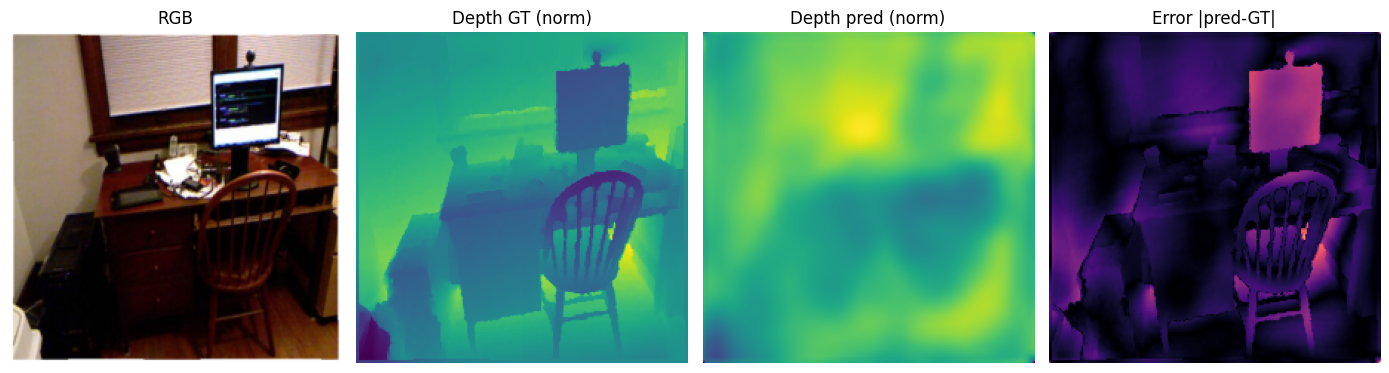

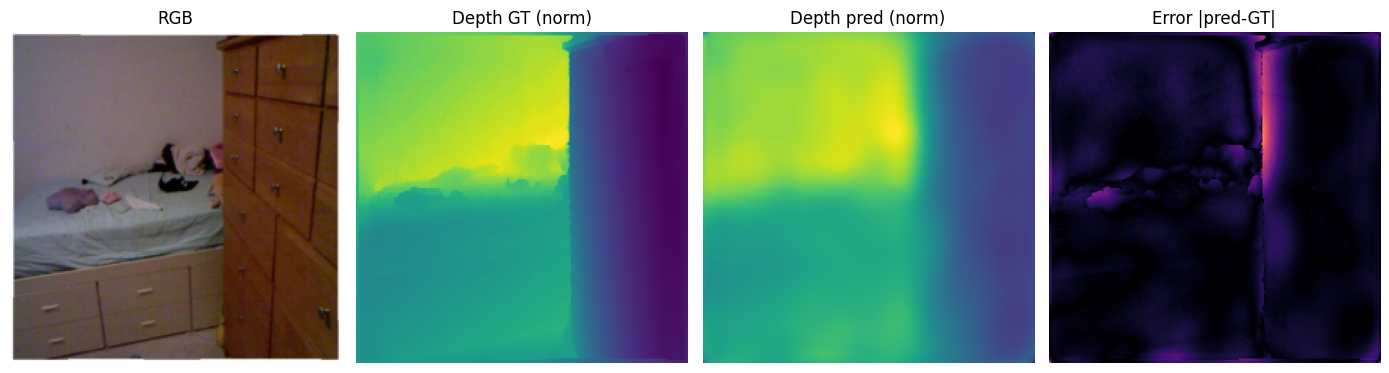

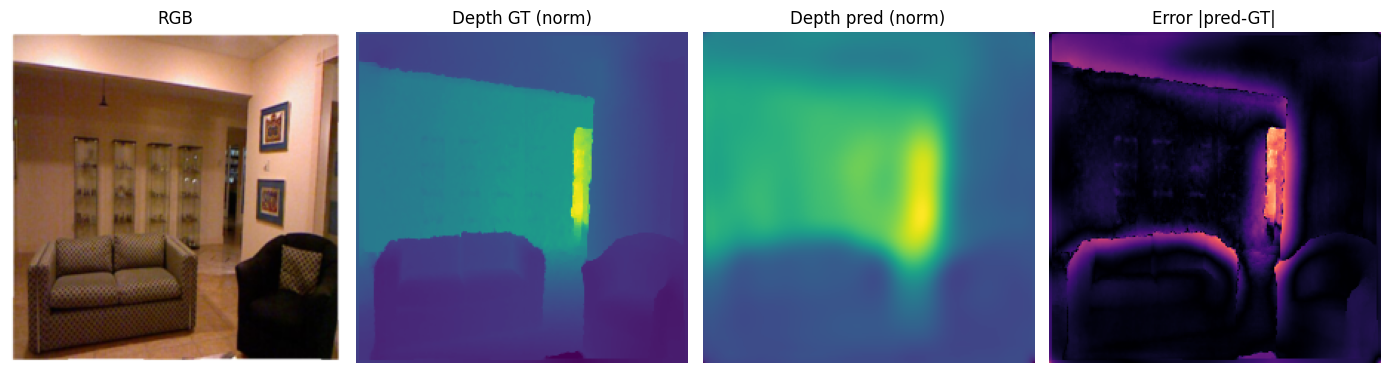

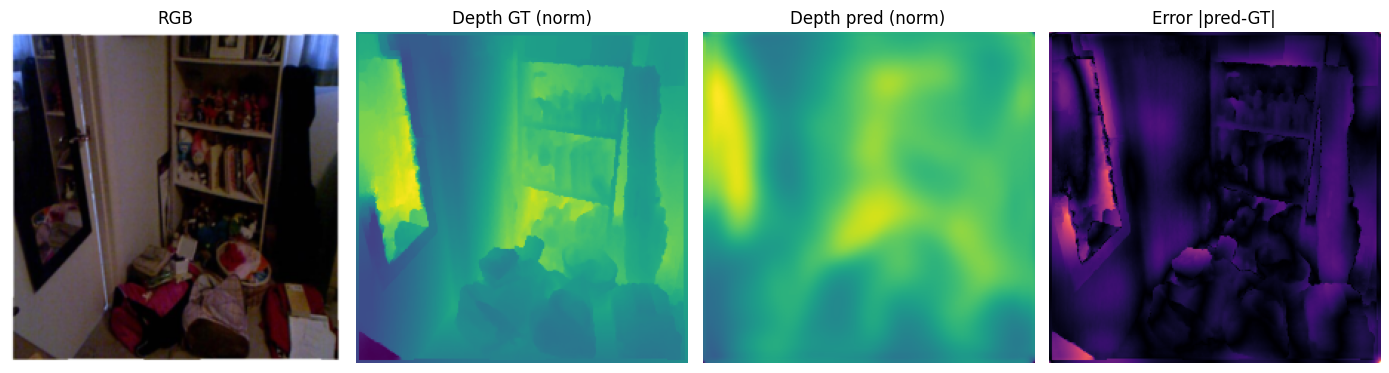

In [8]:
import matplotlib.pyplot as plt
import torch

student.eval()

# toma un batch
batch = next(iter(train_loader))
rgb   = batch["rgb"].to(device)       # [B,3,224,224]
depth = batch["depth"].to(device)     # [B,1,224,224]

# normalizar depth como en el training
depth_clipped = depth.clamp(0.0, MAX_DEPTH_METERS)
depth_norm = depth_clipped / MAX_DEPTH_METERS
rgbd = torch.cat([rgb, depth_norm], dim=1)

with torch.no_grad():
    feat_student, depth_pred = student(rgbd)   # [B,D], [B,1,224,224]

# pasamos a CPU para graficar
rgb_np   = rgb.cpu().numpy()
depth_np = depth_norm.cpu().numpy()        # esto está en [0,1]
pred_np  = depth_pred.cpu().numpy()        # también en [0,1]
err_np   = np.abs(pred_np - depth_np)      # error absoluto

# muestra primeros N ejemplos
N = min(4, rgb_np.shape[0])

for i in range(N):
    fig, axs = plt.subplots(1, 4, figsize=(14, 4))

    # RGB
    axs[0].imshow(np.transpose(rgb_np[i], (1, 2, 0)))
    axs[0].set_title("RGB")
    axs[0].axis("off")

    # Depth GT (normalizada)
    axs[1].imshow(depth_np[i, 0], cmap="viridis")
    axs[1].set_title("Depth GT (norm)")
    axs[1].axis("off")

    # Depth pred
    axs[2].imshow(pred_np[i, 0], cmap="viridis")
    axs[2].set_title("Depth pred (norm)")
    axs[2].axis("off")

    # Error
    axs[3].imshow(err_np[i, 0], cmap="magma")
    axs[3].set_title("Error |pred-GT|")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()


In [9]:
ckpt_path = "theia_rgbd_student_nyu_px.pt"
torch.save({
    "student_state_dict": student.state_dict(),
    "config": {
        "model_name": "theaiinstitute/theia-small-patch16-224-cdiv",
        "max_depth_m": MAX_DEPTH_METERS,
        "lambda_depth": LAMBDA_DEPTH,
    }
}, ckpt_path)

print("Checkpoint guardado en:", ckpt_path)


Checkpoint guardado en: theia_rgbd_student_nyu_px.pt
